# 03 — Final OCR Evaluation

## Number Plate Detection of Vehicles

This notebook performs the final controlled OCR evaluation for the project.

### OCR requirements covered
- OCR on localized number-plate crops
- EasyOCR
- Tesseract
- PaddleOCR as an additional candidate
- Grayscale conversion
- Contrast enhancement using CLAHE
- Binarization using Otsu thresholding
- Bilateral filtering
- Canny edge preprocessing
- OCR text accuracy
- Character accuracy
- OCR confidence
- Unreadable rate
- OCR timing
- Tesseract vs EasyOCR comparison
- Generic Indian-registration post-processing
- Failure analysis
- YOLO → OCR diagnostic crops

The verified OCR benchmark remains frozen. Unverified YOLO crops are used only for diagnostics.

## 1. Colab Setup

Run from a fresh Colab runtime.

In [3]:
# ============================================================
# 1. COLAB SETUP
# ============================================================

!python -m pip install -q "paddlepaddle==3.2.0" -i https://www.paddlepaddle.org.cn/packages/stable/cpu/
!python -m pip install -q "paddleocr[all]"
!python -m pip install -q ultralytics easyocr pytesseract pyyaml "pandas==2.2.3" opencv-python-headless rapidfuzz
!apt-get -qq update
!apt-get -qq install -y tesseract-ocr > /dev/null

from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
from zipfile import ZipFile
import shutil
import re
import time
import warnings

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import paddle
import pytesseract
import easyocr

from paddleocr import PaddleOCR
from rapidfuzz.distance import Levenshtein
from ultralytics import YOLO
from IPython.display import display

warnings.filterwarnings("ignore")

print("Torch CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("Paddle version:", paddle.__version__)
print("Paddle CUDA compiled:", paddle.device.is_compiled_with_cuda())
print("Tesseract:", pytesseract.get_tesseract_version())

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Mounted at /content/drive


/usr/local/lib/python3.13/dist-packages/paddle/utils/cpp_extension/extension_utils.py:718: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)


Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Torch CUDA: True
GPU: Tesla T4
Paddle version: 3.2.0
Paddle CUDA compiled: False
Tesseract: 4.1.1


## 2. Restore Project

In [4]:
# ============================================================
# 2. RESTORE PROJECT
# ============================================================

DRIVE_ROOT = Path("/content/drive/MyDrive")
PROJECT_DIR = Path("/content/number_plate_training")
TEMP_DIR = Path("/content/_ocr_extract")

zip_candidates = [
    DRIVE_ROOT / "number_plate_training.zip",
    DRIVE_ROOT / "Number-Plate-Detection-Final.zip",
]

ZIP_PATH = next((p for p in zip_candidates if p.exists()), None)

if ZIP_PATH is None:
    matches = list(DRIVE_ROOT.rglob("*number*plate*.zip"))
    ZIP_PATH = matches[0] if matches else None

assert ZIP_PATH is not None and ZIP_PATH.exists(), "Project ZIP not found."

if PROJECT_DIR.exists():
    shutil.rmtree(PROJECT_DIR)

if TEMP_DIR.exists():
    shutil.rmtree(TEMP_DIR)

TEMP_DIR.mkdir(parents=True, exist_ok=True)

with ZipFile(ZIP_PATH, "r") as z:
    z.extractall(TEMP_DIR)

candidate_roots = [
    TEMP_DIR / "number_plate_training",
    TEMP_DIR / "Number-Plate-Detection-Final",
    TEMP_DIR,
]

EXTRACTED_ROOT = None
for candidate in candidate_roots:
    if (candidate / "data" / "processed").exists():
        EXTRACTED_ROOT = candidate
        break

assert EXTRACTED_ROOT is not None, "Could not find data/processed in ZIP."

shutil.copytree(EXTRACTED_ROOT, PROJECT_DIR)
shutil.rmtree(TEMP_DIR)

DATA_DIR = PROJECT_DIR / "data" / "processed"
MODEL_PATH = PROJECT_DIR / "models" / "best.pt"
REPORT_DIR = PROJECT_DIR / "reports" / "ocr_final_experiment"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

assert DATA_DIR.exists()
assert MODEL_PATH.exists()

print("Project:", PROJECT_DIR)
print("Data:", DATA_DIR)
print("Model:", MODEL_PATH)
print("Reports:", REPORT_DIR)

Project: /content/number_plate_training
Data: /content/number_plate_training/data/processed
Model: /content/number_plate_training/models/best.pt
Reports: /content/number_plate_training/reports/ocr_final_experiment


## 3. Verify Frozen Dataset

In [5]:
# ============================================================
# 3. VERIFY FROZEN DATASET
# ============================================================

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

rows = []

for split in ["train", "val", "test"]:
    image_dir = DATA_DIR / split / "images"
    label_dir = DATA_DIR / split / "labels"

    images = [
        p for p in image_dir.iterdir()
        if p.is_file() and p.suffix.lower() in IMAGE_EXTS
    ]

    labels = list(label_dir.glob("*.txt"))

    boxes = sum(
        sum(1 for line in lp.read_text().splitlines() if line.strip())
        for lp in labels
    )

    rows.append({
        "split": split,
        "images": len(images),
        "label_files": len(labels),
        "boxes": boxes,
    })

dataset_check = pd.DataFrame(rows)
display(dataset_check)

assert dataset_check["images"].sum() == 115
assert dataset_check["boxes"].sum() == 233
assert dataset_check.set_index("split").loc["train", "images"] == 90
assert dataset_check.set_index("split").loc["val", "images"] == 13
assert dataset_check.set_index("split").loc["test", "images"] == 12

print("✅ Frozen dataset verified")

,split,images,label_files,boxes
0,train,90,90,185
1,val,13,13,23
2,test,12,12,25


✅ Frozen dataset verified


## 4. Load Frozen Verified OCR Benchmark

The OCR score is calculated only on independently verified plate text.

In [6]:
# ============================================================
# 4. LOAD VERIFIED OCR BENCHMARK
# ============================================================

FROZEN_DIR = PROJECT_DIR / "reports" / "ocr_app_frozen"

csv_candidates = [
    FROZEN_DIR / "details.csv",
    FROZEN_DIR / "verified_plates.csv",
    FROZEN_DIR / "ground_truth.csv",
]

BENCHMARK_CSV = next((p for p in csv_candidates if p.exists()), None)

assert BENCHMARK_CSV is not None, (
    "Verified OCR benchmark CSV not found under reports/ocr_app_frozen."
)

benchmark_raw = pd.read_csv(BENCHMARK_CSV)

def normalize_plate(text):
    return re.sub(r"[^A-Z0-9]", "", str(text).upper())

def first_existing(columns, candidates):
    for c in candidates:
        if c in columns:
            return c
    return None

crop_col = first_existing(
    benchmark_raw.columns,
    ["crop_file", "crop", "image_file", "image", "file", "filename"]
)

truth_col = first_existing(
    benchmark_raw.columns,
    ["ground_truth", "plate_text", "text", "label", "verified_text"]
)

assert crop_col is not None, f"Crop column not found. Columns: {list(benchmark_raw.columns)}"
assert truth_col is not None, f"Ground-truth column not found. Columns: {list(benchmark_raw.columns)}"

benchmark = benchmark_raw[[crop_col, truth_col]].copy()
benchmark.columns = ["crop_file", "ground_truth"]

benchmark["crop_file"] = benchmark["crop_file"].astype(str)
benchmark["ground_truth"] = benchmark["ground_truth"].astype(str)
benchmark["ground_truth_norm"] = benchmark["ground_truth"].map(normalize_plate)

benchmark = benchmark[
    benchmark["ground_truth_norm"].str.len() > 0
].reset_index(drop=True)

print("Verified OCR plates:", len(benchmark))
display(benchmark.head())

if len(benchmark) != 19:
    print(f"⚠️ Expected 19 frozen readable plates, found {len(benchmark)}")

Verified OCR plates: 19


,crop_file,ground_truth,ground_truth_norm
0,01_20230620_160337ll_plate_1.jpg,KL01BF8073,KL01BF8073
1,02_20230614_150831ll_plate_1.jpg,KL38J8358,KL38J8358
2,03_20230620_161019ll_plate_1.jpg,KL40A9882,KL40A9882
3,04_20230620_161029ll_plate_1.jpg,KL22N2122,KL22N2122
4,05_20230620_160304ll_plate_1.jpg,KL46T5370,KL46T5370


In [7]:
# ============================================================
# 5. RESOLVE FROZEN CROP FILES
# ============================================================

search_roots = [
    FROZEN_DIR / "crops",
    FROZEN_DIR,
    PROJECT_DIR / "data" / "ocr_benchmark" / "crops",
    PROJECT_DIR,
]

def resolve_crop(name):
    raw = Path(str(name))

    if raw.is_absolute() and raw.exists():
        return raw

    for root in search_roots:
        candidate = root / raw
        if candidate.exists():
            return candidate

    for root in search_roots:
        if root.exists():
            matches = list(root.rglob(raw.name))
            if matches:
                return matches[0]

    return None

benchmark["crop_path"] = benchmark["crop_file"].map(resolve_crop)

missing = benchmark[benchmark["crop_path"].isna()]

if len(missing):
    display(missing[["crop_file", "ground_truth"]])
    raise FileNotFoundError(
        "Some frozen OCR crop images are missing. "
        "Copy the frozen crops into reports/ocr_app_frozen/crops."
    )

print(f"✅ Resolved {len(benchmark)} frozen OCR crops")

✅ Resolved 19 frozen OCR crops


In [8]:
# ============================================================
# 6. VISUAL AUDIT
# ============================================================

cols = 4
rows = int(np.ceil(len(benchmark) / cols))

plt.figure(figsize=(16, rows * 3))

for i, row in benchmark.iterrows():
    img = cv2.imread(str(row["crop_path"]))

    plt.subplot(rows, cols, i + 1)

    if img is not None:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

    plt.title(f"{i+1}. GT: {row['ground_truth_norm']}", fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

## 5. OCR Preprocessing Variants

Six controlled variants are tested:

1. Original
2. Grayscale + 3×
3. CLAHE + 3× — contrast enhancement
4. Otsu + 3× — binarization
5. Bilateral + 3×
6. Canny + 3×

This covers the written OCR requirements and the preprocessing techniques shown in the project brief.

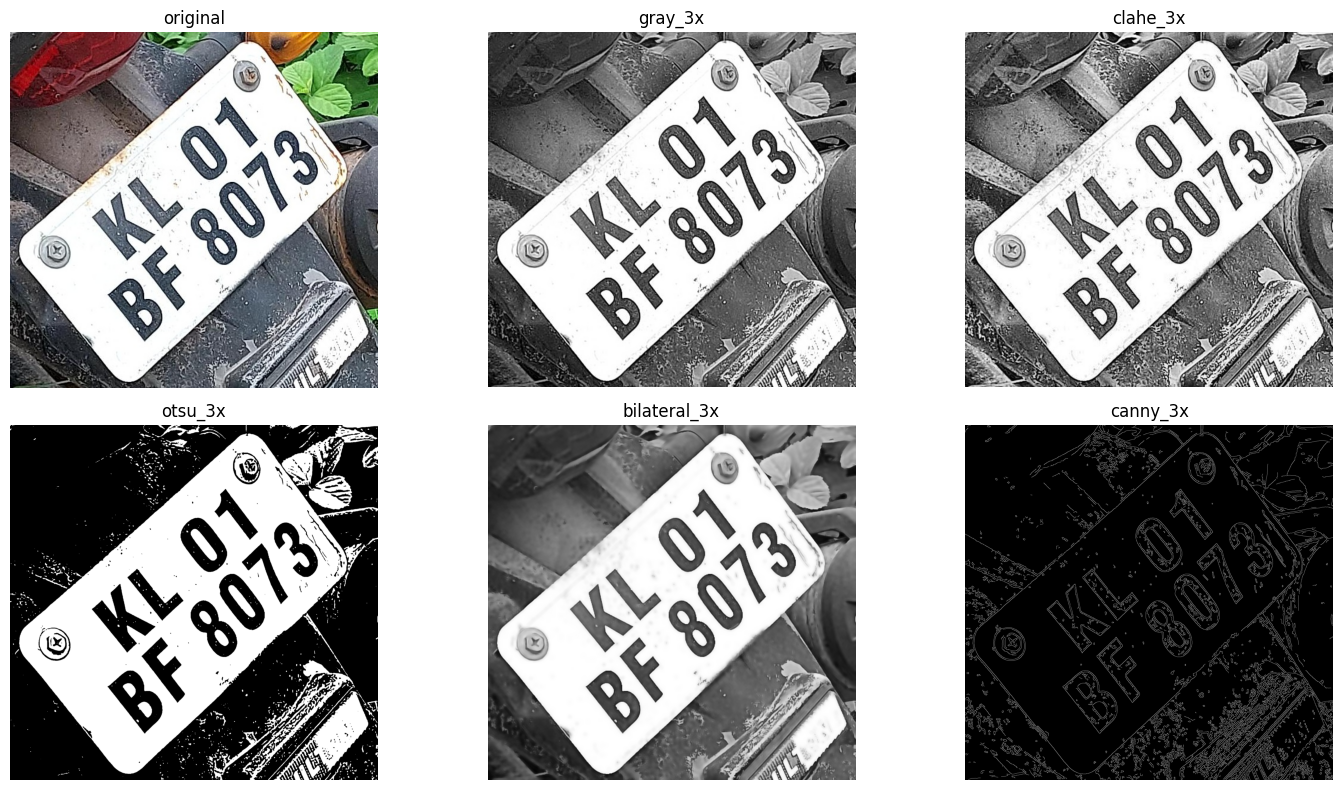

Preprocessing variants: ['original', 'gray_3x', 'clahe_3x', 'otsu_3x', 'bilateral_3x', 'canny_3x']
Total preprocessing variants: 6


In [9]:
# ============================================================
# 7. OCR PREPROCESSING
# ============================================================

def to_gray(image):
    if image.ndim == 2:
        return image
    return cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

def upscale3(image):
    return cv2.resize(
        image,
        None,
        fx=3,
        fy=3,
        interpolation=cv2.INTER_CUBIC
    )

def preprocess_original(image):
    return image.copy()

def preprocess_gray_upscale(image):
    return upscale3(to_gray(image))

def preprocess_clahe_upscale(image):
    gray = to_gray(image)

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    enhanced = clahe.apply(gray)
    return upscale3(enhanced)

def preprocess_otsu_upscale(image):
    gray = upscale3(to_gray(image))

    _, binary = cv2.threshold(
        gray,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    return binary

def preprocess_bilateral_upscale(image):
    gray = to_gray(image)

    filtered = cv2.bilateralFilter(
        gray,
        d=9,
        sigmaColor=75,
        sigmaSpace=75
    )

    return upscale3(filtered)

def preprocess_canny_upscale(image):
    gray = upscale3(to_gray(image))
    gray = cv2.GaussianBlur(gray, (3, 3), 0)

    return cv2.Canny(
        gray,
        100,
        200
    )

PREPROCESSORS = {
    "original": preprocess_original,
    "gray_3x": preprocess_gray_upscale,
    "clahe_3x": preprocess_clahe_upscale,
    "otsu_3x": preprocess_otsu_upscale,
    "bilateral_3x": preprocess_bilateral_upscale,
    "canny_3x": preprocess_canny_upscale,
}

sample = cv2.imread(str(benchmark.iloc[0]["crop_path"]))

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for ax, (name, func) in zip(axes, PREPROCESSORS.items()):
    processed = func(sample)

    if processed.ndim == 2:
        ax.imshow(processed, cmap="gray")
    else:
        ax.imshow(cv2.cvtColor(processed, cv2.COLOR_BGR2RGB))

    ax.set_title(name)
    ax.axis("off")

plt.tight_layout()
plt.show()

print("Preprocessing variants:", list(PREPROCESSORS))
print("Total preprocessing variants:", len(PREPROCESSORS))

## 6. Initialize OCR Engines

In [12]:
# ============================================================
# 8. INITIALIZE OCR ENGINES
# ============================================================

easy_reader = easyocr.Reader(
    ["en"],
    gpu=torch.cuda.is_available(),
    verbose=False
)

paddle_reader = PaddleOCR(
    lang="en",
    use_doc_orientation_classify=False,
    use_doc_unwarping=False,
    use_textline_orientation=False,
)

assert easy_reader is not None
assert paddle_reader is not None

print("✅ EasyOCR initialized")
print("✅ PaddleOCR initialized")
print("✅ Tesseract initialized")

Creating model: ('PP-OCRv6_medium_det', None, None)
Checking connectivity to the model hosters, this may take a while. To bypass this check, set `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` to `True`.
Using official model (PP-OCRv6_medium_det), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-OCRv6_medium_det`.


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Creating model: ('PP-OCRv6_medium_rec', None, None)
Using official model (PP-OCRv6_medium_rec), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-OCRv6_medium_rec`.


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

✅ EasyOCR initialized
✅ PaddleOCR initialized
✅ Tesseract initialized


## 7. OCR Adapters and Generic Indian Plate Cleanup

The benchmark stores both:
- **raw OCR output**
- **final cleaned plate output**

The post-processing is generic and does not contain benchmark answers.

Rules:
- uppercase alphanumeric normalization;
- remove `IND`;
- extract a syntactically plausible Indian registration candidate beginning with a valid state/UT code.

EasyOCR uses line-aware fragment ordering for two-line plates.
Tesseract evaluates PSM 7 and PSM 6 and keeps the more plate-like result.

In [16]:
# ============================================================
# 9. OCR ADAPTERS
# ============================================================

ALLOWED = "ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789"

INDIAN_STATE_CODES = {
    "AP", "AR", "AS", "BR", "CG", "CH", "DD", "DL", "DN",
    "GA", "GJ", "HP", "HR", "JH", "JK", "KA", "KL", "LA",
    "LD", "MH", "ML", "MN", "MP", "MZ", "NL", "OD", "OR",
    "PB", "PY", "RJ", "SK", "TN", "TR", "TS", "UK", "UP", "WB"
}

def clean_indian_plate_candidate(text):
    text = normalize_plate(text)

    if not text:
        return ""

    text = text.replace("IND", "")

    pattern = re.compile(
        r"([A-Z]{2}\d{1,2}[A-Z]{1,3}\d{1,4})"
    )

    matches = pattern.findall(text)

    valid = [
        m for m in matches
        if m[:2] in INDIAN_STATE_CODES
    ]

    if valid:
        return max(valid, key=len)

    return text

def bbox_stats(box):
    xs = [float(p[0]) for p in box]
    ys = [float(p[1]) for p in box]

    return {
        "x": min(xs),
        "cy": (min(ys) + max(ys)) / 2.0,
        "h": max(ys) - min(ys),
    }

def easyocr_reading_order(results):
    if len(results) <= 1:
        return results

    enriched = []

    for item in results:
        try:
            stats = bbox_stats(item[0])
        except Exception:
            stats = {"x": 0.0, "cy": 0.0, "h": 1.0}

        enriched.append((item, stats))

    median_h = np.median([
        max(1.0, s["h"])
        for _, s in enriched
    ])

    threshold = max(5.0, 0.65 * median_h)

    enriched.sort(key=lambda z: z[1]["cy"])

    lines = []

    for item, stats in enriched:
        placed = False

        for line in lines:
            if abs(stats["cy"] - line["cy"]) <= threshold:
                line["items"].append((item, stats))
                line["cy"] = np.mean([
                    s["cy"]
                    for _, s in line["items"]
                ])
                placed = True
                break

        if not placed:
            lines.append({
                "cy": stats["cy"],
                "items": [(item, stats)]
            })

    lines.sort(key=lambda line: line["cy"])

    ordered = []

    for line in lines:
        line["items"].sort(
            key=lambda z: z[1]["x"]
        )

        ordered.extend([
            item
            for item, _ in line["items"]
        ])

    return ordered

def run_easyocr_raw(image):
    results = easy_reader.readtext(
        image,
        detail=1,
        paragraph=False,
        allowlist=ALLOWED
    )

    if not results:
        return "", 0.0

    results = easyocr_reading_order(results)

    raw_text = "".join(
        str(r[1])
        for r in results
    )

    scores = [
        float(r[2])
        for r in results
        if len(r) >= 3
    ]

    return normalize_plate(raw_text), (
        float(np.mean(scores))
        if scores else 0.0
    )

def extract_paddle_raw(result):
    texts = []
    scores = []

    if result is None:
        return "", 0.0

    items = (
        result
        if isinstance(result, (list, tuple))
        else [result]
    )

    for item in items:
        obj = item

        if hasattr(item, "json"):
            try:
                obj = item.json
                if callable(obj):
                    obj = obj()
            except Exception:
                obj = item

        if isinstance(obj, dict):
            if "res" in obj and isinstance(obj["res"], dict):
                obj = obj["res"]

            rec_texts = obj.get("rec_texts", [])
            rec_scores = obj.get("rec_scores", [])

            if rec_texts:
                texts.extend([
                    str(t)
                    for t in rec_texts
                ])

                scores.extend([
                    float(s)
                    for s in rec_scores
                ])

                continue

        if isinstance(item, (list, tuple)):
            stack = list(item)

            if (
                len(stack) == 1
                and isinstance(stack[0], (list, tuple))
            ):
                stack = list(stack[0])

            for entry in stack:
                try:
                    if (
                        isinstance(entry, (list, tuple))
                        and len(entry) >= 2
                        and isinstance(entry[1], (list, tuple))
                        and len(entry[1]) >= 2
                    ):
                        texts.append(
                            str(entry[1][0])
                        )
                        scores.append(
                            float(entry[1][1])
                        )
                except Exception:
                    pass

    return normalize_plate("".join(texts)), (
        float(np.mean(scores))
        if scores else 0.0
    )

def run_paddleocr_raw(image):
    if image.ndim == 2:
        paddle_input = cv2.cvtColor(
            image,
            cv2.COLOR_GRAY2BGR
        )
    else:
        paddle_input = image

    result = paddle_reader.predict(
        input=paddle_input
    )

    return extract_paddle_raw(result)

def run_tesseract_psm(image, psm):
    config = (
        f"--psm {psm} "
        "-c tessedit_char_whitelist="
        "ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789"
    )

    data = pytesseract.image_to_data(
        image,
        config=config,
        output_type=pytesseract.Output.DICT,
        timeout=5
    )

    texts = []
    confs = []

    for txt, conf in zip(
        data["text"],
        data["conf"]
    ):
        txt = normalize_plate(txt)

        try:
            conf = float(conf)
        except Exception:
            conf = -1

        if txt:
            texts.append(txt)

            if conf >= 0:
                confs.append(conf / 100.0)

    raw = normalize_plate("".join(texts))
    avg_conf = (
        float(np.mean(confs))
        if confs else 0.0
    )

    return raw, avg_conf

def plate_likeness(raw_text, confidence):
    cleaned = clean_indian_plate_candidate(raw_text)

    valid_prefix = int(
        len(cleaned) >= 2
        and cleaned[:2] in INDIAN_STATE_CODES
    )

    digit_present = int(
        any(ch.isdigit() for ch in cleaned)
    )

    return (
        valid_prefix * 100
        + digit_present * 10
        + len(cleaned) * 0.01
        + confidence
    )

def run_tesseract_raw(image):
    candidates = []

    for psm in (7, 6):
        raw, conf = run_tesseract_psm(
            image,
            psm
        )

        candidates.append(
            (raw, conf)
        )

    return max(
        candidates,
        key=lambda x: plate_likeness(
            x[0],
            x[1]
        )
    )

OCR_ENGINES = {
    "easyocr": run_easyocr_raw,
    "paddleocr": run_paddleocr_raw,
    "tesseract": run_tesseract_raw,
}

print("OCR engines:", list(OCR_ENGINES))

OCR engines: ['easyocr', 'paddleocr', 'tesseract']


## 8. Health Check

Before running all 342 OCR evaluations, this cell verifies that every engine/preprocessing combination executes successfully on one verified plate.

In [13]:
# ============================================================
# 10. OCR HEALTH CHECK + WARM-UP
# ============================================================

sample_path = benchmark.iloc[0]["crop_path"]
sample = cv2.imread(str(sample_path))

health_rows = []

for engine_name, engine_func in OCR_ENGINES.items():
    for prep_name, prep_func in PREPROCESSORS.items():

        try:
            processed = prep_func(sample)

            start = time.perf_counter()
            raw_pred, conf = engine_func(processed)
            elapsed = (
                time.perf_counter() - start
            ) * 1000

            cleaned = clean_indian_plate_candidate(
                raw_pred
            )

            health_rows.append({
                "engine": engine_name,
                "preprocessing": prep_name,
                "raw_prediction": raw_pred,
                "prediction": cleaned,
                "confidence": conf,
                "time_ms": elapsed,
                "error": "",
            })

        except Exception as e:
            health_rows.append({
                "engine": engine_name,
                "preprocessing": prep_name,
                "raw_prediction": "",
                "prediction": "",
                "confidence": 0.0,
                "time_ms": np.nan,
                "error": f"{type(e).__name__}: {e}",
            })

health_check = pd.DataFrame(
    health_rows
)

display(health_check)

health_errors = health_check[
    health_check["error"].str.len() > 0
]

if len(health_errors):
    display(health_errors)

    raise RuntimeError(
        "OCR health check failed. "
        "Fix the displayed errors before continuing."
    )

assert len(health_check) == 18

print("✅ All 18 engine/preprocessing combinations executed successfully.")

,engine,preprocessing,raw_prediction,prediction,confidence,time_ms,error
0,easyocr,original,3018073BF,3018073BF,0.855000,1128.803291,
1,easyocr,gray_3x,N0180733ILJAN,N0180733ILJAN,0.573127,889.557406,
2,easyocr,clahe_3x,A80734ILJ631,A80734ILJ631,0.445746,730.778976,
3,easyocr,otsu_3x,58073BF,58073BF,0.958237,670.290824,
4,easyocr,bilateral_3x,30180735ILT,30180735ILT,0.566954,708.738509,
5,easyocr,canny_3x,0P983S0880,0P983S0880,0.438184,735.692189,
6,paddleocr,original,KL01BF8073,KL01BF8073,0.986263,1547.409716,
7,paddleocr,gray_3x,58073K,58073K,0.579051,16322.553469,
8,paddleocr,clahe_3x,15L,15L,0.638335,13274.073651,
9,paddleocr,otsu_3x,LG01KL,LG01KL,0.701574,20347.392510,


✅ All 18 engine/preprocessing combinations executed successfully.


## 9. OCR Metrics

In [14]:
# ============================================================
# 11. OCR METRICS
# ============================================================

def character_accuracy(
    ground_truth,
    prediction
):
    gt = normalize_plate(
        ground_truth
    )

    pred = normalize_plate(
        prediction
    )

    if not gt:
        return np.nan

    distance = Levenshtein.distance(
        gt,
        pred
    )

    return max(
        0.0,
        1.0 - distance / len(gt)
    )

def exact_match(
    ground_truth,
    prediction
):
    return int(
        normalize_plate(ground_truth)
        ==
        normalize_plate(prediction)
    )

## 10. Final OCR Benchmark

3 OCR engines × 6 preprocessing variants = 18 configurations per plate.

For the frozen 19-plate benchmark:

**19 × 18 = 342 OCR evaluations**

In [15]:
# ============================================================
# 12. FINAL OCR BENCHMARK
# ============================================================

results = []

for _, row in benchmark.iterrows():

    image = cv2.imread(
        str(row["crop_path"])
    )

    if image is None:
        raise FileNotFoundError(
            row["crop_path"]
        )

    gt = row["ground_truth_norm"]

    for prep_name, prep_func in PREPROCESSORS.items():

        processed = prep_func(
            image
        )

        for engine_name, engine_func in OCR_ENGINES.items():

            try:
                start = time.perf_counter()

                raw_pred, confidence = (
                    engine_func(
                        processed
                    )
                )

                ocr_time_ms = (
                    time.perf_counter() - start
                ) * 1000

                error = ""

            except Exception as e:

                raw_pred = ""
                confidence = 0.0
                ocr_time_ms = np.nan

                error = (
                    f"{type(e).__name__}: {e}"
                )

            raw_pred = normalize_plate(
                raw_pred
            )

            pred = (
                clean_indian_plate_candidate(
                    raw_pred
                )
            )

            results.append({
                "crop_file": row["crop_file"],
                "ground_truth": gt,

                "engine": engine_name,
                "preprocessing": prep_name,

                "raw_prediction": raw_pred,
                "raw_exact_match": exact_match(
                    gt,
                    raw_pred
                ),
                "raw_character_accuracy": character_accuracy(
                    gt,
                    raw_pred
                ),

                "prediction": pred,
                "exact_match": exact_match(
                    gt,
                    pred
                ),
                "character_accuracy": character_accuracy(
                    gt,
                    pred
                ),

                "postprocess_changed": int(
                    raw_pred != pred
                ),

                "confidence": confidence,
                "unreadable": int(
                    raw_pred == ""
                ),

                "ocr_time_ms": ocr_time_ms,
                "error": error,
            })

ocr_results = pd.DataFrame(
    results
)

EXPECTED_ROWS = (
    len(benchmark)
    * len(PREPROCESSORS)
    * len(OCR_ENGINES)
)

assert len(ocr_results) == EXPECTED_ROWS

RESULTS_CSV = (
    REPORT_DIR
    / "ocr_engine_preprocessing_results.csv"
)

ocr_results.to_csv(
    RESULTS_CSV,
    index=False
)

runtime_errors = ocr_results[
    ocr_results["error"].str.len() > 0
]

print("Rows:", len(ocr_results))
print("Expected:", EXPECTED_ROWS)
print("Runtime errors:", len(runtime_errors))
print("Saved:", RESULTS_CSV)

if len(runtime_errors):
    display(
        runtime_errors[
            [
                "crop_file",
                "engine",
                "preprocessing",
                "error"
            ]
        ].head(20)
    )

display(
    ocr_results.head(12)
)

Rows: 342
Expected: 342
Runtime errors: 0
Saved: /content/number_plate_training/reports/ocr_final_experiment/ocr_engine_preprocessing_results.csv


,crop_file,ground_truth,engine,preprocessing,raw_prediction,raw_exact_match,raw_character_accuracy,prediction,exact_match,character_accuracy,postprocess_changed,confidence,unreadable,ocr_time_ms,error
0,01_20230620_160337ll_plate_1.jpg,KL01BF8073,easyocr,original,3018073BF,0,0.4,3018073BF,0,0.4,0,0.855000,0,136.632476,
1,01_20230620_160337ll_plate_1.jpg,KL01BF8073,paddleocr,original,KL01BF8073,1,1.0,KL01BF8073,1,1.0,0,0.986263,0,1212.183848,
2,01_20230620_160337ll_plate_1.jpg,KL01BF8073,tesseract,original,YESSNESIPS8A4YYQSMYZZLANESLEEEPLEIN,0,0.0,YESSNESIPS8A4YYQSMYZZLANESLEEEPLEIN,0,0.0,0,0.223333,0,1085.524193,
3,01_20230620_160337ll_plate_1.jpg,KL01BF8073,easyocr,gray_3x,N0180733ILJAN,0,0.0,N0180733ILJAN,0,0.0,0,0.573127,0,781.193784,
4,01_20230620_160337ll_plate_1.jpg,KL01BF8073,paddleocr,gray_3x,58073K,0,0.3,58073K,0,0.3,0,0.579051,0,13731.641993,
5,01_20230620_160337ll_plate_1.jpg,KL01BF8073,tesseract,gray_3x,SAYFSPLYOA2AMG4AAFMEABE5AOXLLEJSNYVAOSASOOSN47...,0,0.0,AP74S445,0,0.0,1,0.172169,0,4700.311298,
6,01_20230620_160337ll_plate_1.jpg,KL01BF8073,easyocr,clahe_3x,A80734ILJ631,0,0.0,A80734ILJ631,0,0.0,0,0.445746,0,803.661616,
7,01_20230620_160337ll_plate_1.jpg,KL01BF8073,paddleocr,clahe_3x,15L,0,0.1,15L,0,0.1,0,0.638335,0,13894.700534,
8,01_20230620_160337ll_plate_1.jpg,KL01BF8073,tesseract,clahe_3x,9PSZILFSGS4FNISSGAPPCRSBWNM7VCFYSMS74JLRPCFASE...,0,0.0,9PSZILFSGS4FNISSGAPPCRSBWNM7VCFYSMS74JLRPCFASE...,0,0.0,0,0.132544,0,9235.648591,
9,01_20230620_160337ll_plate_1.jpg,KL01BF8073,easyocr,otsu_3x,58073BF,0,0.2,58073BF,0,0.2,0,0.958237,0,745.397445,


## 11. Summary and Best OCR Configuration

In [17]:
# ============================================================
# 13. OCR SUMMARY
# ============================================================

summary = (
    ocr_results
    .groupby(
        [
            "engine",
            "preprocessing"
        ],
        as_index=False
    )
    .agg(
        plates=(
            "crop_file",
            "count"
        ),

        raw_exact_match_accuracy=(
            "raw_exact_match",
            "mean"
        ),

        raw_character_accuracy=(
            "raw_character_accuracy",
            "mean"
        ),

        exact_match_accuracy=(
            "exact_match",
            "mean"
        ),

        character_accuracy=(
            "character_accuracy",
            "mean"
        ),

        average_confidence=(
            "confidence",
            "mean"
        ),

        unreadable_rate=(
            "unreadable",
            "mean"
        ),

        postprocess_change_rate=(
            "postprocess_changed",
            "mean"
        ),

        mean_ocr_time_ms=(
            "ocr_time_ms",
            "mean"
        ),

        runtime_errors=(
            "error",
            lambda s: int(
                (s.str.len() > 0).sum()
            )
        )
    )
    .sort_values(
        [
            "runtime_errors",
            "exact_match_accuracy",
            "character_accuracy"
        ],
        ascending=[
            True,
            False,
            False
        ]
    )
    .reset_index(
        drop=True
    )
)

display(
    summary.style.format({
        "raw_exact_match_accuracy": "{:.2%}",
        "raw_character_accuracy": "{:.2%}",
        "exact_match_accuracy": "{:.2%}",
        "character_accuracy": "{:.2%}",
        "average_confidence": "{:.3f}",
        "unreadable_rate": "{:.2%}",
        "postprocess_change_rate": "{:.2%}",
        "mean_ocr_time_ms": "{:.2f}",
    })
)

SUMMARY_CSV = (
    REPORT_DIR
    / "ocr_engine_summary.csv"
)

summary.to_csv(
    SUMMARY_CSV,
    index=False
)

valid_summary = summary[
    summary["runtime_errors"] == 0
].copy()

assert len(valid_summary)

best = valid_summary.iloc[0]

BEST_ENGINE = best["engine"]
BEST_PREP = best["preprocessing"]

BEST_RAW_EXACT = float(
    best["raw_exact_match_accuracy"]
)

BEST_RAW_CHAR = float(
    best["raw_character_accuracy"]
)

BEST_EXACT = float(
    best["exact_match_accuracy"]
)

BEST_CHAR = float(
    best["character_accuracy"]
)

BEST_OCR_TIME = float(
    best["mean_ocr_time_ms"]
)

print("Best configuration")
print("------------------")
print("Engine:", BEST_ENGINE)
print("Preprocessing:", BEST_PREP)
print("Raw exact match:", f"{BEST_RAW_EXACT:.2%}")
print("Raw character accuracy:", f"{BEST_RAW_CHAR:.2%}")
print("Final exact match:", f"{BEST_EXACT:.2%}")
print("Final character accuracy:", f"{BEST_CHAR:.2%}")
print("Mean OCR time:", f"{BEST_OCR_TIME:.2f} ms/plate")

,engine,preprocessing,plates,raw_exact_match_accuracy,raw_character_accuracy,exact_match_accuracy,character_accuracy,average_confidence,unreadable_rate,postprocess_change_rate,mean_ocr_time_ms,runtime_errors
0,paddleocr,original,19,47.37%,75.03%,84.21%,93.63%,0.928,5.26%,42.11%,1117.39,0
1,paddleocr,bilateral_3x,19,31.58%,54.33%,47.37%,61.11%,0.831,10.53%,26.32%,8376.71,0
2,paddleocr,otsu_3x,19,26.32%,46.90%,36.84%,52.57%,0.715,15.79%,15.79%,8456.00,0
3,easyocr,gray_3x,19,10.53%,42.92%,21.05%,54.44%,0.674,0.00%,31.58%,545.70,0
4,easyocr,original,19,10.53%,48.07%,21.05%,53.92%,0.676,0.00%,21.05%,102.10,0
5,easyocr,otsu_3x,19,10.53%,43.10%,21.05%,50.70%,0.687,0.00%,21.05%,539.54,0
6,paddleocr,gray_3x,19,15.79%,39.42%,21.05%,44.09%,0.650,26.32%,10.53%,8477.42,0
7,paddleocr,clahe_3x,19,10.53%,31.05%,21.05%,37.89%,0.656,26.32%,21.05%,8466.55,0
8,easyocr,bilateral_3x,19,10.53%,42.69%,15.79%,49.53%,0.680,0.00%,26.32%,555.79,0
9,easyocr,clahe_3x,19,5.26%,40.82%,10.53%,50.41%,0.668,0.00%,31.58%,556.59,0


Best configuration
------------------
Engine: paddleocr
Preprocessing: original
Raw exact match: 47.37%
Raw character accuracy: 75.03%
Final exact match: 84.21%
Final character accuracy: 93.63%
Mean OCR time: 1117.39 ms/plate


## 12. Best Tesseract vs EasyOCR vs PaddleOCR

In [18]:
# ============================================================
# 14. BEST CONFIGURATION PER ENGINE
# ============================================================

engine_best = (
    valid_summary
    .sort_values(
        [
            "engine",
            "exact_match_accuracy",
            "character_accuracy"
        ],
        ascending=[
            True,
            False,
            False
        ]
    )
    .groupby(
        "engine",
        as_index=False
    )
    .head(1)
    .reset_index(
        drop=True
    )
)

display(
    engine_best[
        [
            "engine",
            "preprocessing",
            "raw_exact_match_accuracy",
            "exact_match_accuracy",
            "character_accuracy",
            "unreadable_rate",
            "mean_ocr_time_ms",
        ]
    ].style.format({
        "raw_exact_match_accuracy": "{:.2%}",
        "exact_match_accuracy": "{:.2%}",
        "character_accuracy": "{:.2%}",
        "unreadable_rate": "{:.2%}",
        "mean_ocr_time_ms": "{:.2f}",
    })
)

engine_best.to_csv(
    REPORT_DIR
    / "ocr_best_per_engine.csv",
    index=False
)

,engine,preprocessing,raw_exact_match_accuracy,exact_match_accuracy,character_accuracy,unreadable_rate,mean_ocr_time_ms
0,easyocr,gray_3x,10.53%,21.05%,54.44%,0.00%,545.70
1,paddleocr,original,47.37%,84.21%,93.63%,5.26%,1117.39
2,tesseract,original,0.00%,0.00%,10.18%,10.53%,722.35


## 13. Project 90%+ OCR Target Assessment

In [19]:
# ============================================================
# 15. OCR TARGET ASSESSMENT
# ============================================================

TARGET = 0.90

if BEST_EXACT >= TARGET:

    status = "ACHIEVED"

    explanation = (
        "The best OCR configuration reached at least "
        "90% strict full-plate exact-match accuracy "
        "on the verified benchmark."
    )

elif BEST_CHAR >= TARGET:

    status = (
        "CHARACTER-LEVEL >=90%, "
        "STRICT EXACT-MATCH TARGET NOT ACHIEVED"
    )

    explanation = (
        "Average character accuracy reached at least 90%, "
        "but strict full-plate exact-match accuracy remained below 90%."
    )

else:

    status = "NOT ACHIEVED"

    explanation = (
        "Neither strict exact-match accuracy nor average "
        "character accuracy reached 90% on the verified benchmark."
    )

print("Project OCR target:", "90%+")
print("Best strict exact match:", f"{BEST_EXACT:.2%}")
print("Best character accuracy:", f"{BEST_CHAR:.2%}")
print("Target assessment:", status)
print()
print(explanation)

Project OCR target: 90%+
Best strict exact match: 84.21%
Best character accuracy: 93.63%
Target assessment: CHARACTER-LEVEL >=90%, STRICT EXACT-MATCH TARGET NOT ACHIEVED

Average character accuracy reached at least 90%, but strict full-plate exact-match accuracy remained below 90%.


## 14. Failure Analysis

In [20]:
# ============================================================
# 16. FAILURE ANALYSIS
# ============================================================

best_rows = ocr_results[
    (ocr_results["engine"] == BEST_ENGINE)
    &
    (ocr_results["preprocessing"] == BEST_PREP)
].copy()

best_rows = best_rows.sort_values(
    [
        "character_accuracy",
        "exact_match"
    ],
    ascending=[
        True,
        True
    ]
).reset_index(
    drop=True
)

display(
    best_rows[
        [
            "crop_file",
            "ground_truth",
            "raw_prediction",
            "prediction",
            "postprocess_changed",
            "exact_match",
            "character_accuracy",
            "confidence",
        ]
    ].style.format({
        "character_accuracy": "{:.2%}",
        "confidence": "{:.3f}",
    })
)

,crop_file,ground_truth,raw_prediction,prediction,postprocess_changed,exact_match,character_accuracy,confidence
0,16_20230614_150927ll_plate_1.jpg,KL07BT2347,,,0,0,0.00%,0.000
1,04_20230620_161029ll_plate_1.jpg,KL22N2122,KL22M2122IND,KL22M2122,1,0,88.89%,0.999
2,18_20230620_161026ll_plate_1.jpg,KL01CJ4909,L01CJ4909,L01CJ4909,0,0,90.00%,0.996
3,01_20230620_160337ll_plate_1.jpg,KL01BF8073,KL01BF8073,KL01BF8073,0,1,100.00%,0.986
4,02_20230614_150831ll_plate_1.jpg,KL38J8358,KL38J8358IND,KL38J8358,1,1,100.00%,1.000
5,03_20230620_161019ll_plate_1.jpg,KL40A9882,KL40A9882,KL40A9882,0,1,100.00%,0.994
6,05_20230620_160304ll_plate_1.jpg,KL46T5370,KL46T5370,KL46T5370,0,1,100.00%,0.961
7,06_20230620_160353ll_plate_1.jpg,KL01AS8270,EVKL01AS8270,KL01AS8270,1,1,100.00%,0.995
8,07_20230620_161031ll_plate_1.jpg,KL01BR8934,KL01BR8934,KL01BR8934,0,1,100.00%,0.958
9,08_20230620_160735ll_plate_1.jpg,KA51HB0288,KA51HB0288,KA51HB0288,0,1,100.00%,1.000


## 15. YOLO → OCR Diagnostic Crops

These crops are for end-to-end inspection only. They are not used for OCR accuracy unless the text is independently verified.

In [21]:
# ============================================================
# 17. YOLO TEST-CROP DIAGNOSTIC
# ============================================================

detector = YOLO(
    str(MODEL_PATH)
)

TEST_IMAGE_DIR = (
    DATA_DIR
    / "test"
    / "images"
)

YOLO_CROP_DIR = (
    REPORT_DIR
    / "yolo_test_crops"
)

YOLO_CROP_DIR.mkdir(
    parents=True,
    exist_ok=True
)

diagnostic_rows = []

for image_path in sorted(
    TEST_IMAGE_DIR.iterdir()
):

    if (
        image_path.suffix.lower()
        not in IMAGE_EXTS
    ):
        continue

    image = cv2.imread(
        str(image_path)
    )

    if image is None:
        continue

    pred = detector.predict(
        source=image,
        conf=0.10,
        imgsz=832,
        verbose=False,
        device=0
        if torch.cuda.is_available()
        else "cpu",
    )[0]

    if pred.boxes is None:
        continue

    for j, box in enumerate(
        pred.boxes
    ):

        x1, y1, x2, y2 = (
            box.xyxy[0]
            .cpu()
            .numpy()
            .astype(int)
        )

        h, w = image.shape[:2]

        x1 = max(0, x1)
        y1 = max(0, y1)
        x2 = min(w, x2)
        y2 = min(h, y2)

        crop = image[
            y1:y2,
            x1:x2
        ]

        if crop.size == 0:
            continue

        crop_name = (
            f"{image_path.stem}"
            f"_pred_{j:02d}.jpg"
        )

        crop_path = (
            YOLO_CROP_DIR
            / crop_name
        )

        cv2.imwrite(
            str(crop_path),
            crop
        )

        diagnostic_rows.append({
            "source_image": image_path.name,
            "crop_file": crop_name,
            "confidence": float(
                box.conf[0].cpu()
            ),
            "x1": x1,
            "y1": y1,
            "x2": x2,
            "y2": y2,
        })

diagnostic_df = pd.DataFrame(
    diagnostic_rows
)

diagnostic_csv = (
    REPORT_DIR
    / "yolo_test_crop_manifest.csv"
)

diagnostic_df.to_csv(
    diagnostic_csv,
    index=False
)

print(
    "YOLO diagnostic crops:",
    len(diagnostic_df)
)

print(
    "Manifest:",
    diagnostic_csv
)

display(
    diagnostic_df.head()
)

YOLO diagnostic crops: 33
Manifest: /content/number_plate_training/reports/ocr_final_experiment/yolo_test_crop_manifest.csv


,source_image,crop_file,confidence,x1,y1,x2,y2
0,20230614_151238ll.jpg,20230614_151238ll_pred_00.jpg,0.797784,1024,1275,1579,1608
1,20230614_151246ll.jpg,20230614_151246ll_pred_00.jpg,0.487577,1067,913,1667,1270
2,20230620_160118ll.jpg,20230620_160118ll_pred_00.jpg,0.922714,1775,1970,2389,2631
3,20230620_160118ll.jpg,20230620_160118ll_pred_01.jpg,0.676437,2420,72,2594,364
4,20230620_160204ll.jpg,20230620_160204ll_pred_00.jpg,0.599779,936,612,1028,659


## 16. Automatic Final OCR Conclusion

In [22]:
# ============================================================
# 18. FINAL OCR CONCLUSION
# ============================================================

final_lines = [
    "FINAL OCR EVALUATION CONCLUSION",
    "-------------------------------",
    "",
    f"Verified benchmark size: {len(benchmark)} plates",
    f"Total controlled OCR evaluations: {len(ocr_results)}",
    "",
    "OCR engines compared:",
    "- EasyOCR",
    "- PaddleOCR",
    "- Tesseract",
    "",
    "Preprocessing compared:",
    "- Original",
    "- Grayscale + 3x upscale",
    "- CLAHE + 3x upscale",
    "- Otsu + 3x upscale",
    "- Bilateral filter + 3x upscale",
    "- Canny edges + 3x upscale",
    "",
    "Best OCR configuration:",
    f"Engine: {BEST_ENGINE}",
    f"Preprocessing: {BEST_PREP}",
    "",
    f"Raw strict exact-match accuracy: {BEST_RAW_EXACT:.2%}",
    f"Raw character accuracy: {BEST_RAW_CHAR:.2%}",
    f"Final strict exact-match accuracy: {BEST_EXACT:.2%}",
    f"Final character accuracy: {BEST_CHAR:.2%}",
    f"Mean OCR time: {BEST_OCR_TIME:.2f} ms/plate",
    "",
    "Project OCR target: 90%+",
    f"Target assessment: {status}",
    "",
    "Interpretation:",
    explanation,
    "",
    "Methodology notes:",
    "- OCR accuracy is based only on independently verified plate text.",
    "- Raw OCR and post-processed OCR scores are both reported.",
    "- Generic Indian plate post-processing does not use benchmark answers.",
    "- Unverified YOLO crops are diagnostic only.",
    "- Detector and OCR performance are reported separately.",
]

final_text = "\n".join(
    final_lines
)

print(final_text)

FINAL_TXT = (
    REPORT_DIR
    / "FINAL_OCR_CONCLUSION.txt"
)

FINAL_TXT.write_text(
    final_text
)

print()
print("✅ Saved:", FINAL_TXT)

FINAL OCR EVALUATION CONCLUSION
-------------------------------

Verified benchmark size: 19 plates
Total controlled OCR evaluations: 342

OCR engines compared:
- EasyOCR
- PaddleOCR
- Tesseract

Preprocessing compared:
- Original
- Grayscale + 3x upscale
- CLAHE + 3x upscale
- Otsu + 3x upscale
- Bilateral filter + 3x upscale
- Canny edges + 3x upscale

Best OCR configuration:
Engine: paddleocr
Preprocessing: original

Raw strict exact-match accuracy: 47.37%
Raw character accuracy: 75.03%
Final strict exact-match accuracy: 84.21%
Final character accuracy: 93.63%
Mean OCR time: 1117.39 ms/plate

Project OCR target: 90%+
Target assessment: CHARACTER-LEVEL >=90%, STRICT EXACT-MATCH TARGET NOT ACHIEVED

Interpretation:
Average character accuracy reached at least 90%, but strict full-plate exact-match accuracy remained below 90%.

Methodology notes:
- OCR accuracy is based only on independently verified plate text.
- Raw OCR and post-processed OCR scores are both reported.
- Generic Indian

## 17. Export OCR Reports to Google Drive

In [23]:
# ============================================================
# 19. EXPORT RESULTS
# ============================================================

DRIVE_RESULTS = (
    Path("/content/drive/MyDrive")
    / "Number-Plate-Detection-Training-Results"
    / "reports"
    / "ocr_final_experiment"
)

DRIVE_RESULTS.mkdir(
    parents=True,
    exist_ok=True
)

for file_path in REPORT_DIR.glob("*"):

    if file_path.is_file():
        shutil.copy2(
            file_path,
            DRIVE_RESULTS / file_path.name
        )

if YOLO_CROP_DIR.exists():

    drive_crop_dir = (
        DRIVE_RESULTS
        / "yolo_test_crops"
    )

    if drive_crop_dir.exists():
        shutil.rmtree(
            drive_crop_dir
        )

    shutil.copytree(
        YOLO_CROP_DIR,
        drive_crop_dir
    )

print(
    "✅ OCR reports exported to:",
    DRIVE_RESULTS
)

✅ OCR reports exported to: /content/drive/MyDrive/Number-Plate-Detection-Training-Results/reports/ocr_final_experiment


# Final OCR Coverage Checklist

- ✅ EasyOCR
- ✅ Tesseract
- ✅ PaddleOCR
- ✅ Original image
- ✅ Grayscale
- ✅ CLAHE contrast enhancement
- ✅ Otsu binarization
- ✅ Bilateral filter
- ✅ Canny edges
- ✅ 19 verified OCR ground-truth plates
- ✅ 342 controlled OCR evaluations
- ✅ Exact-match accuracy
- ✅ Character accuracy
- ✅ Confidence
- ✅ Unreadable rate
- ✅ Runtime-error tracking
- ✅ OCR timing
- ✅ Tesseract vs EasyOCR comparison
- ✅ Generic Indian plate post-processing
- ✅ Raw vs post-processed scores
- ✅ Failure analysis
- ✅ YOLO end-to-end diagnostic crops
- ✅ 90% target assessment
- ✅ No unverified OCR text counted as accuracy